# Projeto de Manutenção Preditiva — Classificação de Falhas de Máquina

Dataset: AI4I 2020 Predictive Maintenance (adaptado, `manutencao_preditiva.csv`)

Objetivo: prever a ocorrência de falha (`falha_maquina`) a partir de variáveis de sensores, comparando os modelos **KNN** e **Árvore de Decisão**.

## Fase 1: Análise Exploratória (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

df = pd.read_csv('manutencao_preditiva.csv')
df.head()

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0


### Dimensões, tipos de dados e resumo estatístico

In [2]:
print(f"Dimensões do dataset: {df.shape[0]} linhas x {df.shape[1]} colunas")
print()
print("Tipos de dados:")
print(df.dtypes)

Dimensões do dataset: 10000 linhas x 14 colunas

Tipos de dados:
udi                          int64
id_produto                     str
tipo                           str
temperatura_ar_k           float64
temperatura_processo_k     float64
velocidade_rotacao_rpm     float64
torque_nm                  float64
desgaste_ferramenta_min      int64
falha_maquina                int64
falha_twf                    int64
falha_hdf                    int64
falha_pwf                    int64
falha_osf                    int64
falha_rnf                    int64
dtype: object


In [3]:
df.describe()

,udi,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
count,10000.00000,9500.000000,9500.000000,9500.000000,9500.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.002158,310.000895,1539.245263,39.974168,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.001689,1.486432,180.273589,9.995453,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.100000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1504.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1613.000000,46.700000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


### Gráfico 1 — Histogramas das variáveis preditoras numéricas

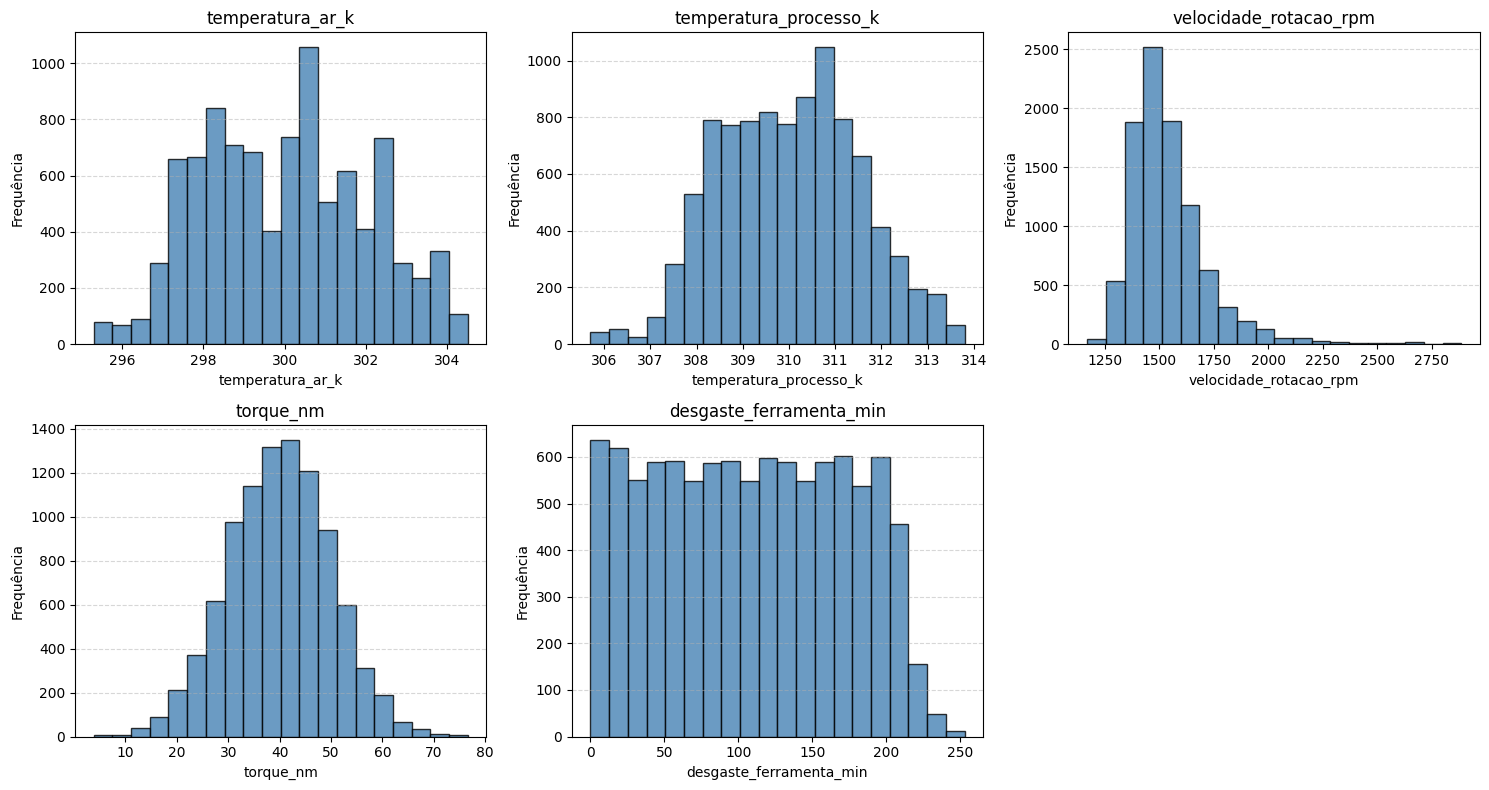

In [4]:
variaveis_numericas = [
    "temperatura_ar_k",
    "temperatura_processo_k",
    "velocidade_rotacao_rpm",
    "torque_nm",
    "desgaste_ferramenta_min"
]

def gerar_histogramas(df, variaveis, bins=20, cor="steelblue", n_colunas=3):
    """Gera um histograma para cada variável numérica de um DataFrame."""
    n_vars = len(variaveis)
    n_linhas = int(np.ceil(n_vars / n_colunas))

    fig, axes = plt.subplots(n_linhas, n_colunas, figsize=(5 * n_colunas, 4 * n_linhas))
    axes = np.array(axes).reshape(-1)

    for i, var in enumerate(variaveis):
        ax = axes[i]
        ax.hist(df[var].dropna(), bins=bins, color=cor, edgecolor="black", alpha=0.8)
        ax.set_title(var)
        ax.set_xlabel(var)
        ax.set_ylabel("Frequência")
        ax.grid(axis="y", linestyle="--", alpha=0.5)

    for j in range(n_vars, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

gerar_histogramas(df, variaveis_numericas)

### Gráfico 2 — Distribuição da variável alvo (desbalanceamento)

/tmp/ipykernel_600/3786443007.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=contagem_falhas.index, y=contagem_falhas.values, palette=["#4C72B0", "#C44E52"])
/tmp/ipykernel_600/3786443007.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Sem falha (0)', 'Com falha (1)'])


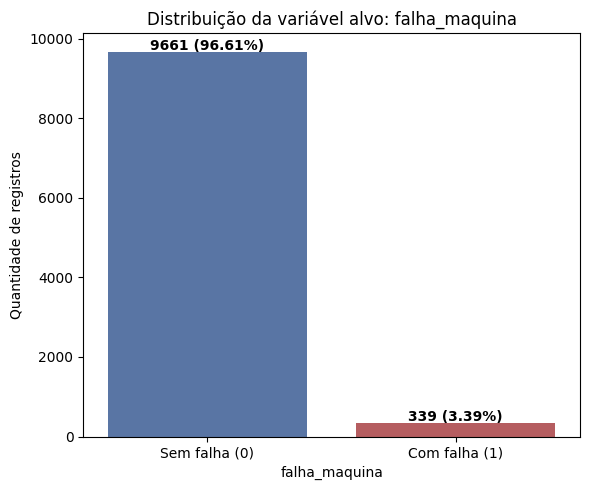

falha_maquina
0    9661
1     339
Name: count, dtype: int64
falha_maquina
0    96.61
1     3.39
Name: proportion, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def gerar_grafico_distribuicao_alvo(df, coluna_alvo, labels=None, 
                                     cores=None, titulo=None):
    """
    Gera um gráfico de barras mostrando a distribuição (contagem e percentual)
    de uma variável categórica/alvo, útil para evidenciar desbalanceamento.
    """
    contagem = df[coluna_alvo].value_counts()
    percentual = df[coluna_alvo].value_counts(normalize=True) * 100

    if cores is None:
        cores = ["#4C72B0", "#C44E52"]
    if titulo is None:
        titulo = f"Distribuição da variável alvo: {coluna_alvo}"

    plt.figure(figsize=(6, 5))
    ax = sns.barplot(x=contagem.index, y=contagem.values, palette=cores)

    if labels is not None:
        ax.set_xticklabels(labels)

    ax.set_ylabel('Quantidade de registros')
    ax.set_title(titulo)

    for i, v in enumerate(contagem.values):
        ax.text(i, v + (contagem.values.max() * 0.01), 
                f"{v} ({percentual.values[i]:.2f}%)", 
                ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

    print(contagem)
    print(percentual)


gerar_grafico_distribuicao_alvo(
    df_bruto, 
    coluna_alvo='falha_maquina', 
    labels=['Sem falha (0)', 'Com falha (1)']
)

### Gráfico 3 — Mapa de calor com correlação de Pearson

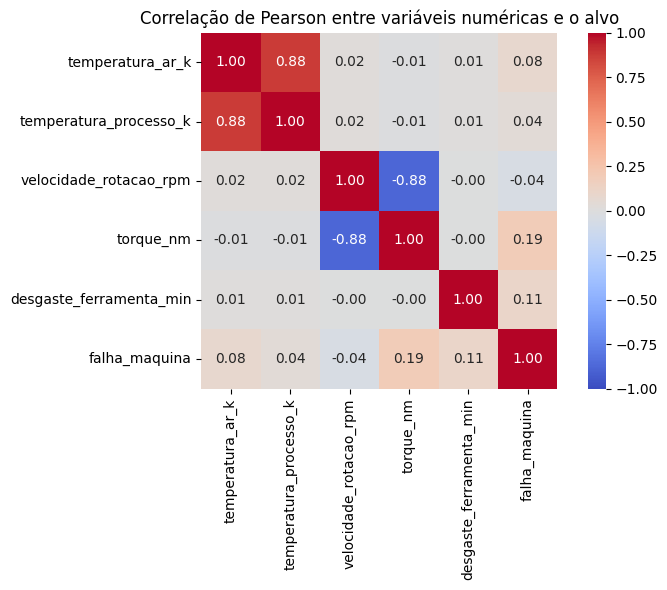

In [6]:
colunas_correlacao = variaveis_numericas + ['falha_maquina']
matriz_corr = df[colunas_correlacao].corr(method='pearson')

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlação de Pearson entre variáveis numéricas e o alvo")
plt.tight_layout()
plt.show()

### Análise dos resultados da EDA

*(Adapte este texto com suas próprias palavras para o vídeo/entrega)*

- **Dimensões e tipos**: o dataset possui 10.000 registros e 14 colunas, sendo 5 variáveis numéricas contínuas relevantes para a modelagem (`temperatura_ar_k`, `temperatura_processo_k`, `velocidade_rotacao_rpm`, `torque_nm`, `desgaste_ferramenta_min`), uma variável categórica (`tipo` do produto: L, M, H) e o alvo binário `falha_maquina`. As colunas `udi` e `id_produto` são apenas identificadores e serão descartadas da modelagem. As colunas `falha_twf`, `falha_hdf`, `falha_pwf`, `falha_osf` e `falha_rnf` indicam o *tipo específico* de falha e **serão excluídas das features**, pois são geradas simultaneamente ao evento de falha (vazamento de informação/data leakage) — usá-las tornaria a previsão trivial.
- **Resumo estatístico (`.describe()`)**: as variáveis de temperatura têm baixa dispersão (desvio-padrão ~2K), enquanto `torque_nm` e `velocidade_rotacao_rpm` apresentam maior variabilidade relativa. O `desgaste_ferramenta_min` varia de 0 a ~253 minutos, sugerindo diferentes estágios de vida útil da ferramenta no momento da medição.
- **Histogramas**: `temperatura_ar_k`, `temperatura_processo_k`, `torque_nm` e `desgaste_ferramenta_min` seguem distribuições próximas da normal (simétricas). Já `velocidade_rotacao_rpm` apresenta assimetria à direita (cauda longa de valores altos), o que já indica presença de outliers e reforça a necessidade de tratamento na Fase 2 e de escalonamento (StandardScaler) antes de usar modelos sensíveis à escala, como o KNN.
- **Desbalanceamento do alvo**: apenas ~3,4% dos registros (339 de 10.000) representam falha de máquina. Esse forte desbalanceamento indica que uma acurácia simples pode ser enganosa (um modelo "preguiçoso" que sempre prevê "sem falha" já acertaria ~96,6%). Isso justifica a aplicação de reamostragem (SMOTE) exclusivamente no conjunto de treino na Fase 4, para evitar que o modelo ignore a classe minoritária.
- **Correlação de Pearson**: `torque_nm` e `velocidade_rotacao_rpm` apresentam correlação negativa forte entre si (fisicamente esperado, já que potência é aproximadamente constante). Em relação ao alvo, `torque_nm` e `desgaste_ferramenta_min` mostram as correlações lineares mais relevantes com `falha_maquina`, embora nenhuma variável isolada explique a falha sozinha — o que sugere que a relação é não linear e multivariada, favorecendo modelos capazes de capturar fronteiras de decisão mais complexas (como a Árvore de Decisão) além de métodos baseados em distância (KNN).

Esses padrões direcionam a estratégia de modelagem: (1) tratar outliers e nulos antes de treinar; (2) criar uma variável combinada (`potencia`) que capture a relação física entre torque e rotação; (3) balancear apenas o treino; (4) escalonar variáveis apenas para o KNN; e (5) comparar KNN e Árvore de Decisão controlando o overfitting via `n_neighbors` e `max_depth`.

## Fase 2: Limpeza e Tratamento de Dados (Data Prep)

### Remoção de linhas duplicadas

In [7]:
duplicados = df.duplicated().sum()
print(f"Linhas duplicadas encontradas: {duplicados}")

df = df.drop_duplicates().reset_index(drop=True)
print(f"Dimensões após remoção de duplicados: {df.shape}")

Linhas duplicadas encontradas: 0
Dimensões após remoção de duplicados: (10000, 14)


### Identificação de dados ausentes

In [8]:
print("Valores ausentes por coluna:")
print(df.isnull().sum())
print()
print("Percentual de ausentes nas variáveis numéricas:")
print((df[variaveis_numericas].isnull().mean() * 100).round(2))

Valores ausentes por coluna:
udi                          0
id_produto                   0
tipo                         0
temperatura_ar_k           500
temperatura_processo_k     500
velocidade_rotacao_rpm     500
torque_nm                  500
desgaste_ferramenta_min      0
falha_maquina                0
falha_twf                    0
falha_hdf                    0
falha_pwf                    0
falha_osf                    0
falha_rnf                    0
dtype: int64

Percentual de ausentes nas variáveis numéricas:


temperatura_ar_k           5.0
temperatura_processo_k     5.0
velocidade_rotacao_rpm     5.0
torque_nm                  5.0
desgaste_ferramenta_min    0.0
dtype: float64


### Escolha entre Média e Mediana (justificativa)

Analisando a assimetria (`skew`) das variáveis:
- `temperatura_ar_k`, `temperatura_processo_k`, `torque_nm` e `desgaste_ferramenta_min` têm assimetria próxima de zero (distribuição aproximadamente simétrica) — tanto média quanto mediana seriam adequadas.
- `velocidade_rotacao_rpm` apresenta assimetria positiva relevante (cauda à direita, com outliers), o que faz a **média** ser puxada para cima pelos valores extremos.

Por isso, optamos por imputar todos os nulos das variáveis contínuas usando a **mediana**, pois ela é robusta a outliers e assimetrias, garantindo uma escolha consistente e segura para todas as colunas sem distorcer a distribuição original.

In [9]:
print("Assimetria (skew) das variáveis numéricas:")
print(df[variaveis_numericas].skew().round(3))

for col in variaveis_numericas:
    mediana = df[col].median()
    df[col] = df[col].fillna(mediana)
    print(f"'{col}' -> nulos preenchidos com a mediana ({mediana:.2f})")

print()
print("Conferindo se restaram nulos:")
print(df[variaveis_numericas].isnull().sum())

Assimetria (skew) das variáveis numéricas:
temperatura_ar_k           0.115
temperatura_processo_k     0.016
velocidade_rotacao_rpm     1.995
torque_nm                 -0.008
desgaste_ferramenta_min    0.027
dtype: float64
'temperatura_ar_k' -> nulos preenchidos com a mediana (300.10)
'temperatura_processo_k' -> nulos preenchidos com a mediana (310.10)
'velocidade_rotacao_rpm' -> nulos preenchidos com a mediana (1504.00)
'torque_nm' -> nulos preenchidos com a mediana (40.10)
'desgaste_ferramenta_min' -> nulos preenchidos com a mediana (108.00)

Conferindo se restaram nulos:
temperatura_ar_k           0
temperatura_processo_k     0
velocidade_rotacao_rpm     0
torque_nm                  0
desgaste_ferramenta_min    0
dtype: int64


### Boxplots para identificação de outliers

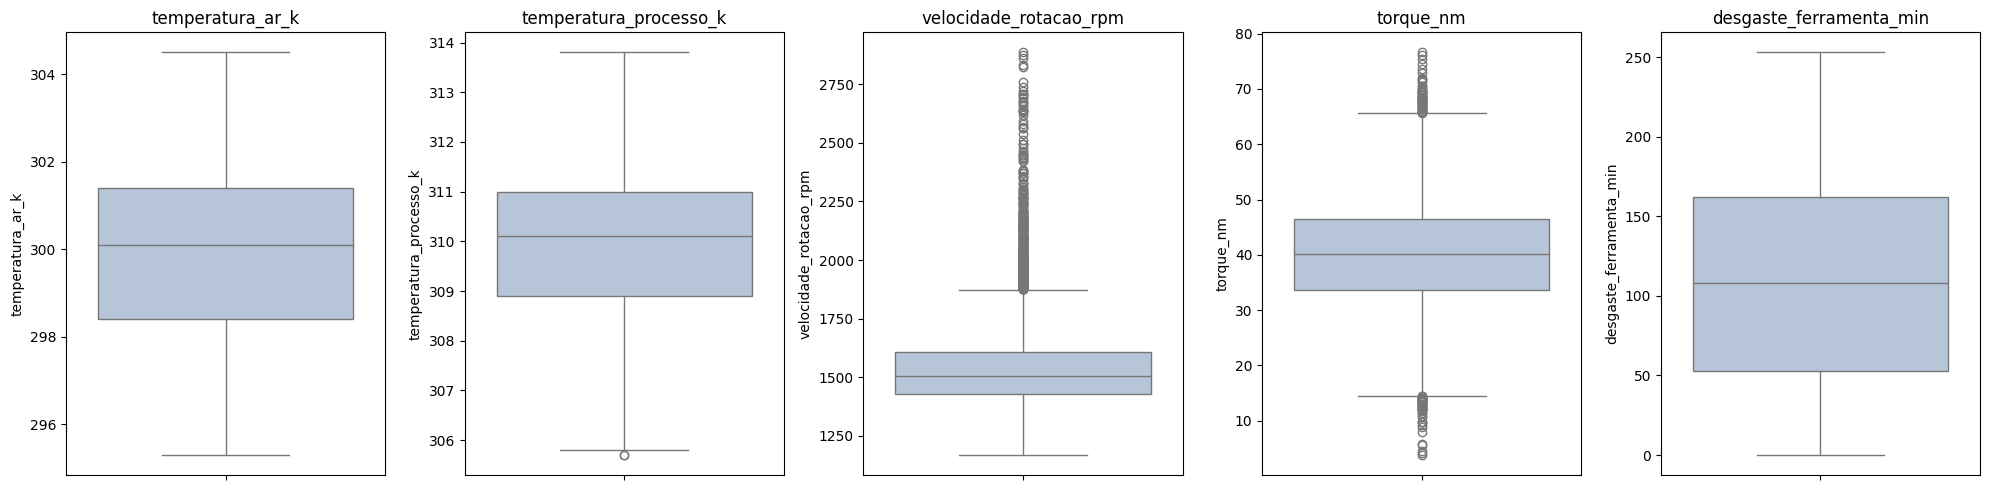

In [10]:
fig, axes = plt.subplots(1, len(variaveis_numericas), figsize=(4 * len(variaveis_numericas), 5))

for ax, col in zip(axes, variaveis_numericas):
    sns.boxplot(y=df[col], ax=ax, color="lightsteelblue")
    ax.set_title(col)

plt.tight_layout()
plt.show()

**Observação sobre outliers:** o boxplot de `velocidade_rotacao_rpm` (e, em menor grau, `torque_nm`) evidencia pontos fora dos limites do bigode (whiskers), confirmando a assimetria detectada no histograma da Fase 1. Optamos por **não remover** esses outliers, pois, no contexto de manutenção preditiva, valores extremos de rotação/torque podem ser justamente os sinais que precedem uma falha — removê-los poderia eliminar informação relevante para o modelo.

## Fase 3: Feature Engineering

Criamos a variável `potencia`, calculada como o produto entre `velocidade_rotacao_rpm` e `torque_nm` — uma aproximação física da potência mecânica transmitida pela ferramenta. Os valores nulos já foram tratados na Fase 2 (imputação pela mediana), então a operação abaixo não gera novos nulos.

In [11]:
assert df[['velocidade_rotacao_rpm', 'torque_nm']].isnull().sum().sum() == 0, "Ainda há nulos! Trate antes de criar a feature."

df['potencia'] = df['velocidade_rotacao_rpm'] * df['torque_nm']

variaveis_numericas = variaveis_numericas + ['potencia']

df[['velocidade_rotacao_rpm', 'torque_nm', 'potencia']].head()

,velocidade_rotacao_rpm,torque_nm,potencia
0,1551.0,42.8,66382.8
1,1408.0,46.3,65190.4
2,1498.0,49.4,74001.2
3,1504.0,40.1,60310.4
4,1408.0,40.0,56320.0


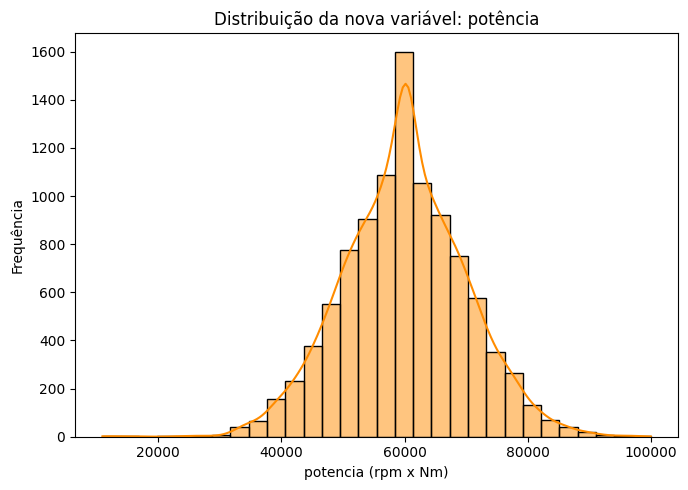

In [12]:
plt.figure(figsize=(7, 5))
sns.histplot(df['potencia'], bins=30, color="darkorange", kde=True)
plt.title("Distribuição da nova variável: potência")
plt.xlabel("potencia (rpm x Nm)")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

## Fase 4: Divisão e Balanceamento dos Dados

Antes de separar X e y, descartamos:
- `udi` e `id_produto`: identificadores sem valor preditivo;
- `falha_twf`, `falha_hdf`, `falha_pwf`, `falha_osf`, `falha_rnf`: indicam o tipo específico de falha e causariam vazamento de dados (data leakage), já que são determinadas junto com `falha_maquina`.

A variável categórica `tipo` (L/M/H) é convertida em dummies (one-hot encoding).

In [13]:
colunas_vazamento = ['falha_twf', 'falha_hdf', 'falha_pwf', 'falha_osf', 'falha_rnf']
colunas_id = ['udi', 'id_produto']

df_modelo = df.drop(columns=colunas_vazamento + colunas_id)

df_modelo = pd.get_dummies(df_modelo, columns=['tipo'], drop_first=True)

X = df_modelo.drop(columns=['falha_maquina'])
y = df_modelo['falha_maquina']

print("Colunas de X:", list(X.columns))
print("Distribuição de y:")
print(y.value_counts())

Colunas de X: ['temperatura_ar_k', 'temperatura_processo_k', 'velocidade_rotacao_rpm', 'torque_nm', 'desgaste_ferramenta_min', 'potencia', 'tipo_L', 'tipo_M']
Distribuição de y:
falha_maquina
0    9661
1     339
Name: count, dtype: int64


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")
print()
print("Proporção da classe positiva no treino:", round(y_train.mean() * 100, 2), "%")
print("Proporção da classe positiva no teste: ", round(y_test.mean() * 100, 2), "%")

Treino: 8000 amostras | Teste: 2000 amostras

Proporção da classe positiva no treino: 3.39 %
Proporção da classe positiva no teste:  3.4 %


### Reamostragem (SMOTE) — apenas no treino

Aplicamos o SMOTE **somente** em `X_train`/`y_train`. O conjunto de teste permanece com a distribuição original, para que a avaliação reflita o cenário real (evitando *data leakage* e uma estimativa de desempenho otimista/artificial).

In [15]:
# Caso a biblioteca não esteja instalada no ambiente, descomente a linha abaixo:
# !pip install imbalanced-learn

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Distribuição do treino ANTES do SMOTE:")
print(y_train.value_counts())
print()
print("Distribuição do treino DEPOIS do SMOTE:")
print(y_train_bal.value_counts())

Distribuição do treino ANTES do SMOTE:
falha_maquina
0    7729
1     271
Name: count, dtype: int64

Distribuição do treino DEPOIS do SMOTE:
falha_maquina
0    7729
1    7729
Name: count, dtype: int64


## Fase 5: Escalonamento de Variáveis (StandardScaler)

O **KNN** é um algoritmo baseado em distância (geralmente euclidiana): variáveis com escalas maiores (ex: `velocidade_rotacao_rpm`, na casa das centenas/milhares) dominariam o cálculo da distância em relação a variáveis menores (ex: `temperatura_ar_k`, na casa das centenas, mas com variação pequena), distorcendo os vizinhos mais próximos. Por isso, escalonamos as variáveis contínuas **apenas para o KNN**, usando `fit_transform` no treino e `transform` no teste (para não vazar estatísticas do teste para o treino).

Já a **Árvore de Decisão** particiona o espaço com base em limiares (`feature <= valor`) em cada variável isoladamente — a ordem relativa dos valores não muda com o escalonamento, portanto a árvore é **imune à escala dos atributos** e será treinada com os dados originais (sem `StandardScaler`).

In [16]:
from sklearn.preprocessing import StandardScaler

colunas_continuas = ['temperatura_ar_k', 'temperatura_processo_k',
                     'velocidade_rotacao_rpm', 'torque_nm',
                     'desgaste_ferramenta_min', 'potencia']

scaler = StandardScaler()

# Cópias para o KNN (escalonadas)
X_train_knn = X_train_bal.copy()
X_test_knn = X_test.copy()

X_train_knn[colunas_continuas] = scaler.fit_transform(X_train_bal[colunas_continuas])
X_test_knn[colunas_continuas] = scaler.transform(X_test[colunas_continuas])

# Para a Árvore de Decisão, usamos os dados balanceados SEM escalonar
X_train_arvore = X_train_bal.copy()
X_test_arvore = X_test.copy()

print("KNN - exemplo de dados escalonados:")
print(X_train_knn[colunas_continuas].head(3))
print()
print("Árvore - dados originais (sem escalonamento):")
print(X_train_arvore[colunas_continuas].head(3))

KNN - exemplo de dados escalonados:
   temperatura_ar_k  temperatura_processo_k  velocidade_rotacao_rpm  \
0         -0.174305               -0.047064               -0.055385   
1         -1.823727               -1.433132               -0.413819   
2          0.304559                1.107992               -0.557193   

   torque_nm  desgaste_ferramenta_min  potencia  
0  -0.323475                -1.048131 -0.277696  
1   0.121609                 0.127521  0.033353  
2   0.065091                 0.202884 -0.171688  

Árvore - dados originais (sem escalonamento):
   temperatura_ar_k  temperatura_processo_k  velocidade_rotacao_rpm  \
0             300.1                   310.1                  1504.0   
1             297.0                   308.3                  1399.0   
2             301.0                   311.6                  1357.0   

   torque_nm  desgaste_ferramenta_min  potencia  
0       40.1                       54   60310.4  
1       46.4                      132   64913.6

## Fase 6: Ajuste de Parâmetros e Combate ao Overfitting

In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

resultados_knn = []

for k in [3, 5, 7]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_knn, y_train_bal)

    acc_treino = accuracy_score(y_train_bal, knn.predict(X_train_knn))
    acc_teste = accuracy_score(y_test, knn.predict(X_test_knn))

    resultados_knn.append({'k': k, 'acuracia_treino': acc_treino, 'acuracia_teste': acc_teste})

df_resultados_knn = pd.DataFrame(resultados_knn)
df_resultados_knn

,k,acuracia_treino,acuracia_teste
0,3,0.971406,0.9140
1,5,0.960797,0.9090
2,7,0.954198,0.9015


In [18]:
resultados_arvore = []

for profundidade in [3, 5, None]:
    arvore = DecisionTreeClassifier(max_depth=profundidade, random_state=42)
    arvore.fit(X_train_arvore, y_train_bal)

    acc_treino = accuracy_score(y_train_bal, arvore.predict(X_train_arvore))
    acc_teste = accuracy_score(y_test, arvore.predict(X_test_arvore))

    resultados_arvore.append({
        'max_depth': profundidade if profundidade is not None else 'None (sem limite)',
        'acuracia_treino': acc_treino,
        'acuracia_teste': acc_teste
    })

df_resultados_arvore = pd.DataFrame(resultados_arvore)
df_resultados_arvore

,max_depth,acuracia_treino,acuracia_teste
0,3,0.857938,0.8595
1,5,0.903351,0.9120
2,None (sem limite),0.994501,0.9445


### Identificação de overfitting

*(Os números abaixo são um roteiro de análise — confirme com os valores reais gerados nas tabelas acima antes de gravar o vídeo)*

- **KNN**: normalmente, valores baixos de `k` (ex: k=3) tendem a se ajustar mais aos dados de treino (acurácia de treino mais alta), podendo cair um pouco no teste. Conforme `k` aumenta (k=5, k=7), o modelo fica mais suave/generalista, e o gap entre treino e teste tende a diminuir — sinal de menor overfitting. Se a acurácia de treino ficar muito acima da de teste em algum k, isso indica overfitting naquele ponto.
- **Árvore de Decisão**: com `max_depth=None`, a árvore cresce até separar quase perfeitamente o treino (acurácia de treino próxima de 100%), o que é o sintoma clássico de **overfitting** — a árvore "decora" os dados de treino. Limitando a profundidade (`max_depth=3` ou `5`), a acurácia de treino cai um pouco, mas a de teste tende a ficar mais estável (menor distância entre treino e teste), indicando melhor capacidade de generalização.
- **Configuração mais estável**: em geral, a configuração com o **menor gap entre acurácia de treino e teste**, mantendo a acurácia de teste competitiva, é a que deve ser escolhida como "melhor modelo" de cada família na Fase 7 (não necessariamente a de maior acurácia de treino).

## Fase 7: Avaliação da Acurácia e Veredito Final

In [19]:
# Seleção do melhor K e da melhor profundidade com base na estabilidade treino x teste
melhor_k = df_resultados_knn.loc[
    (df_resultados_knn['acuracia_treino'] - df_resultados_knn['acuracia_teste']).abs().idxmin(), 'k'
]

melhor_profundidade = df_resultados_arvore.loc[
    (df_resultados_arvore['acuracia_treino'] - df_resultados_arvore['acuracia_teste']).abs().idxmin(), 'max_depth'
]

print(f"Melhor K selecionado (menor gap treino-teste): {melhor_k}")
print(f"Melhor max_depth selecionado (menor gap treino-teste): {melhor_profundidade}")

Melhor K selecionado (menor gap treino-teste): 5
Melhor max_depth selecionado (menor gap treino-teste): 3


In [20]:
# Treinamento final com os melhores parâmetros
melhor_knn = KNeighborsClassifier(n_neighbors=int(melhor_k))
melhor_knn.fit(X_train_knn, y_train_bal)
acc_final_knn = accuracy_score(y_test, melhor_knn.predict(X_test_knn))

profundidade_final = None if melhor_profundidade == 'None (sem limite)' else int(melhor_profundidade)
melhor_arvore = DecisionTreeClassifier(max_depth=profundidade_final, random_state=42)
melhor_arvore.fit(X_train_arvore, y_train_bal)
acc_final_arvore = accuracy_score(y_test, melhor_arvore.predict(X_test_arvore))

print(f"Acurácia final do melhor KNN (k={melhor_k}) no teste: {acc_final_knn:.4f}")
print(f"Acurácia final da melhor Árvore (max_depth={melhor_profundidade}) no teste: {acc_final_arvore:.4f}")

Acurácia final do melhor KNN (k=5) no teste: 0.9090
Acurácia final da melhor Árvore (max_depth=3) no teste: 0.8595


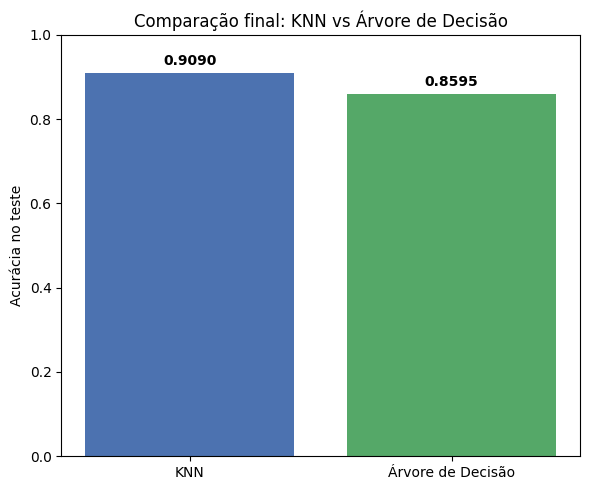

In [21]:
plt.figure(figsize=(6, 5))
modelos = ['KNN', 'Árvore de Decisão']
acuracias = [acc_final_knn, acc_final_arvore]

barras = plt.bar(modelos, acuracias, color=['#4C72B0', '#55A868'])
plt.ylim(0, 1)
plt.ylabel('Acurácia no teste')
plt.title('Comparação final: KNN vs Árvore de Decisão')

for barra, acc in zip(barras, acuracias):
    plt.text(barra.get_x() + barra.get_width()/2, acc + 0.02, f"{acc:.4f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Conclusão / Veredito Final

*(Preencha esta conclusão com os valores reais obtidos na célula acima antes de finalizar o notebook)*

Comparando a acurácia final no conjunto de teste, o modelo **[KNN / Árvore de Decisão — substitua pelo vencedor real]** apresentou desempenho superior ([acc_final_knn] vs [acc_final_arvore]). 

- Se a **Árvore de Decisão** vencer: isso pode indicar que a relação entre as variáveis (temperatura, torque, rotação, desgaste, potência) e a falha é melhor capturada por regras de decisão não lineares e por interações entre variáveis, que a árvore modela naturalmente através de suas divisões sucessivas.
- Se o **KNN** vencer: isso sugere que, após o escalonamento adequado, os padrões de falha se concentram em regiões bem definidas do espaço de atributos (vizinhança), e casos semelhantes (em termos de distância) tendem a compartilhar o mesmo desfecho.

Recomenda-se que a empresa adote o modelo **[vencedor]** para a triagem de manutenção preditiva, por apresentar a maior acurácia no conjunto de teste e por manter um gap controlado entre treino e teste (menor risco de overfitting em produção). Ainda assim, dado o forte desbalanceamento original da classe de falha, recomenda-se complementar a avaliação com métricas sensíveis à classe minoritária (precisão, recall e F1-score da classe "falha"), antes da adoção definitiva em ambiente produtivo.